# Ewaluacja modeli kalibracji fisheye

Notebook porównuje trzy sieci neuronowe z klasyczną kalibracją `cv2.fisheye.calibrate()` na niezależnym zbiorze `data/fisheye_camera_test_seq`. Wyniki są liczone dla każdej sekwencji, a następnie agregowane w tabelach i wykresach.
## 1. Konfiguracja ścieżek, parametrów i kryteriów oceny

Sieci zwracają wektor `[fx, fy, cx, cy, k1, k2, k3, k4]`. Współczynniki ogniskowej i punktu głównego są porównywane w pikselach, a współczynniki dystorsji bez jednostki.
## 2. Import bibliotek oraz modułów projektu

Importy są wykonywane z katalogu repozytorium, aby notebook korzystał z tych samych klas modeli co trening.
## 3–4. Wczytanie danych i przygotowanie wejścia

Każda próbka jest jedną sekwencją 10 obrazów. Narożniki 9×9 są wykrywane i zamieniane na cztery cechy używane przez modele corner: współrzędne znormalizowane oraz standaryzowane.
## 5. Wczytanie trzech modeli neuronowych

Checkpointy są ładowane zarówno z konfiguracją treningu, jak i z samym `state_dict`. Architektura jest wybierana na podstawie nazwy katalogu lub konfiguracji checkpointu.
## 6. Klasyczna kalibracja fisheye

Dla każdej sekwencji wykonywana jest niezależna detekcja narożników i `cv2.fisheye.calibrate()`. Sekwencje z mniej niż trzema poprawnymi klatkami są odrzucane.
## 7–9. Predykcja i metryki

Dla każdej metody obliczane są błędy względem parametrów zapisanych w `camera_params.yaml`, a dla wyników kalibracji również błąd reprojekcji.
## 10–11. Tabele, wykresy i ranking

Mniejszy błąd oznacza lepszy wynik. Ranking główny używa RMSE parametrów, a przy remisie uwzględnia błąd reprojekcji i odsetek poprawnych kalibracji.
## 12. Zapis wyników

Notebook zapisuje wyniki szczegółowe, statystyki oraz konfigurację eksperymentu do katalogu `outputs/fisheye_evaluation`.

In [18]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from torch.utils.data import DataLoader, TensorDataset

ROOT = Path('/home/dbabiarczyk/studia/semestr10/camera_calibration')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.networks_tool.models.fisheye_corner_lstm_sequence import FisheyeCornerLSTMSequenceCalibrationNet
from src.networks_tool.models.fisheye_corner_ssm_sequence import FisheyeCornerSSMSequenceCalibrationNet

CHECKPOINTS = {
    'CalibrationNet Fisheye': ROOT / 'outputs/calibration_net_fisheye/best_model.pth',
    'CalibrationNet Fisheye LSTM': ROOT / 'outputs/calibration_net_fisheye_lstm/best_model.pth',
    'CalibrationNet Fisheye SSM': ROOT / 'outputs/calibration_net_fisheye_ssm/best_model.pth',
}
DATA_DIR = ROOT / 'data/fisheye_camera_test_seq'
RESULTS_DIR = ROOT / 'outputs/fisheye_evaluation'
# These values must match the Full HD coordinate system used during training.
IMAGE_WIDTH, IMAGE_HEIGHT = 1920, 1080
SEQUENCE_LENGTH = 10
BOARD_SQUARES_X, BOARD_SQUARES_Y = 10, 10
PATTERN_SIZE = (BOARD_SQUARES_X - 1, BOARD_SQUARES_Y - 1)
SQUARE_SIZE_PX = 30.0
PARAMETERS = ['fx', 'fy', 'cx', 'cy', 'k1', 'k2', 'k3', 'k4']
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 16
MAIN_METRIC = 'rmse_parameter_px_equiv'
TOLERANCE = {
    'fx': 0.10, 'fy': 0.10, 'cx': 0.10, 'cy': 0.10,
    'k1': 0.05, 'k2': 0.05, 'k3': 0.05, 'k4': 0.05,
}
print(f'Device: {DEVICE}')
print(f'Test sequences: {DATA_DIR}')
assert DATA_DIR.exists(), f'Brak katalogu testowego: {DATA_DIR}'
assert all(path.exists() for path in CHECKPOINTS.values()), 'Brak co najmniej jednego checkpointu.'

Device: cpu
Test sequences: /home/dbabiarczyk/studia/semestr10/camera_calibration/data/fisheye_camera_test_seq


In [47]:
from __future__ import annotations

import json
import sys
import pathlib
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import yaml

sys.modules.setdefault("pathlib._local", pathlib)

ROOT = Path.cwd()
if ROOT.name != "camera_calibration":
    ROOT = Path("/home/dbabiarczyk/studia/semestr10/camera_calibration")
DATA_DIR = ROOT / "data" / "fisheye_camera_test_seq"
RESULTS_DIR = ROOT / "outputs" / "fisheye_evaluation"
IMAGE_WIDTH, IMAGE_HEIGHT = 1920, 1080
BOARD_SQUARES_X, BOARD_SQUARES_Y = 10, 10
PATTERN_SIZE = (BOARD_SQUARES_X - 1, BOARD_SQUARES_Y - 1)
SEQUENCE_LENGTH = 10
SQUARE_SIZE_PX = 80.0
UPSCALE_FOR_DETECTION = 4


def detect_corners(image_path: Path) -> np.ndarray | None:
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None
    enlarged = cv2.resize(image, None, fx=UPSCALE_FOR_DETECTION, fy=UPSCALE_FOR_DETECTION, interpolation=cv2.INTER_CUBIC)
    flags = cv2.CALIB_CB_ADAPTIVE_THRESH | cv2.CALIB_CB_NORMALIZE_IMAGE
    if hasattr(cv2, 'findChessboardCornersSB'):
        found, corners = cv2.findChessboardCornersSB(enlarged, PATTERN_SIZE, flags)
    else:
        found, corners = cv2.findChessboardCorners(enlarged, PATTERN_SIZE, flags)
        if found:
            corners = cv2.cornerSubPix(enlarged, corners, (11, 11), (-1, -1),
                (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001))
    return (corners.astype(np.float64) / UPSCALE_FOR_DETECTION) if found else None


def corners_to_features(corners: np.ndarray) -> np.ndarray:
    points = corners.reshape(-1, 2).copy()
    centered = points - points.mean(axis=0, keepdims=True)
    standardized = centered / np.maximum(centered.std(axis=0, keepdims=True), 1e-6)
    return np.concatenate([points, standardized], axis=1).astype(np.float32)


def load_test_sequences() -> tuple[list[dict], list[dict]]:
    samples, rejected = [], []
    for sequence_dir in sorted(DATA_DIR.glob('sequence_*')):
        frames = sorted(sequence_dir.glob('aug_*.png'))
        if len(frames) < SEQUENCE_LENGTH:
            rejected.append({'sequence': sequence_dir.name, 'reason': 'too_few_frames'})
            continue
        frame_corners = [detect_corners(path) for path in frames[:SEQUENCE_LENGTH]]
        if any(corners is None for corners in frame_corners):
            rejected.append({'sequence': sequence_dir.name, 'reason': 'corner_detection_failed'})
            continue
        params_path = sequence_dir / 'camera_params.yaml'
        params = yaml.safe_load(params_path.read_text()) if params_path.exists() else {}
        ground_truth = np.array([params[key] for key in ('fx', 'fy', 'cx', 'cy', 'k1', 'k2', 'k3', 'k4')], dtype=np.float64)
        samples.append({'sequence': sequence_dir.name, 'frames': frames[:SEQUENCE_LENGTH],
                        'corners': frame_corners, 'ground_truth': ground_truth,
                        'features': np.stack([corners_to_features(c) for c in frame_corners])})
    return samples, rejected

samples, rejected = load_test_sequences()
print(f"Poprawne sekwencje: {len(samples)}, odrzucone: {len(rejected)}")
if rejected:
    display(pd.DataFrame(rejected))
features = torch.tensor(np.stack([sample['features'] for sample in samples]), dtype=torch.float32) if samples else torch.empty((0, SEQUENCE_LENGTH, 81, 4))
print("Wejście sieci:", tuple(features.shape), "(sekwencje, klatki, punkty, cechy)")

Poprawne sekwencje: 20, odrzucone: 0
Wejście sieci: (20, 10, 81, 4) (sekwencje, klatki, punkty, cechy)


In [40]:
def checkpoint_config(checkpoint: dict):
    config = checkpoint.get('config')
    return config


def config_value(config, name: str, default=None):
    if config is None:
        return default
    if isinstance(config, dict):
        return config.get(name, default)
    return getattr(config, name, default)


def load_fisheye_model(label: str, checkpoint_path: Path):
    # Older checkpoints may pickle pathlib.PosixPath as pathlib._local.PosixPath.
    # Alias the historical module name before deserializing the checkpoint.
    import pathlib
    sys.modules.setdefault('pathlib._local', pathlib)
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    config = checkpoint.get('config') if isinstance(checkpoint, dict) else None
    model_name = str(config_value(config, 'model_name', '')).lower()
    if 'lstm' in label.lower() or 'lstm' in model_name:
        model = FisheyeCornerLSTMSequenceCalibrationNet(num_outputs=8, num_points=81)
    elif 'ssm' in label.lower() or 'ssm' in model_name:
        model = FisheyeCornerSSMSequenceCalibrationNet(num_outputs=8, num_points=81)
    else:
        from src.networks_tool.models.fisheye_corner_gru_sequence import FisheyeCornerGRUSequenceCalibrationNet
        model = FisheyeCornerGRUSequenceCalibrationNet(num_outputs=8, num_points=81)
    state_dict = checkpoint.get('model_state_dict', checkpoint.get('state_dict', checkpoint))
    if not isinstance(state_dict, dict):
        raise TypeError(f'Nieznany format checkpointu: {checkpoint_path}')
    model.load_state_dict(state_dict, strict=True)
    model.to(DEVICE).eval()
    parameter_count = sum(parameter.numel() for parameter in model.parameters())
    return model, {
        'checkpoint': str(checkpoint_path),
        'model_name': model_name or label,
        'epoch': checkpoint.get('epoch') if isinstance(checkpoint, dict) else None,
        'parameter_count': parameter_count,
    }


models, model_info = {}, []
for label, path in CHECKPOINTS.items():
    model, info = load_fisheye_model(label, path)
    models[label] = model
    model_info.append({'method': label, **info})
model_info_df = pd.DataFrame(model_info)
display(model_info_df)

,method,checkpoint,model_name,epoch,parameter_count
0,CalibrationNet Fisheye,/home/dbabiarczyk/studia/semestr10/camera_cali...,fisheye_corner_gru_sequence,28,140648
1,CalibrationNet Fisheye LSTM,/home/dbabiarczyk/studia/semestr10/camera_cali...,fisheye_corner_lstm_sequence,53,301672
2,CalibrationNet Fisheye SSM,/home/dbabiarczyk/studia/semestr10/camera_cali...,fisheye_corner_ssm_sequence,12,85224


In [33]:
def calibrate_classical(sample: dict) -> dict | None:
    detected = [corners for corners in sample['corners'] if corners is not None]
    if len(detected) < 3:
        return None
    obj = object_points()
    object_list = [obj.copy() for _ in detected]
    image_size = (IMAGE_WIDTH, IMAGE_HEIGHT)
    K = np.array([[IMAGE_WIDTH, 0, IMAGE_WIDTH / 2], [0, IMAGE_WIDTH, IMAGE_HEIGHT / 2], [0, 0, 1]], dtype=np.float64)
    D = np.zeros((4, 1), dtype=np.float64)
    flags = cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-6)
    try:
        rms, K, D, rvecs, tvecs = cv2.fisheye.calibrate(
            object_list, detected, image_size, K, D, None, None,
            flags=flags, criteria=criteria,
        )
    except cv2.error as error:
        print(f'Klasyczna kalibracja nieudana dla {sample["sequence"]}: {error}')
        return None
    reprojected = []
    for obj_i, rvec, tvec, observed in zip(object_list, rvecs, tvecs, detected):
        projected, _ = cv2.fisheye.projectPoints(obj_i, rvec, tvec, K, D)
        reprojected.append(float(np.mean(np.linalg.norm(projected.reshape(-1, 2) - observed.reshape(-1, 2), axis=1))))
    predicted = np.array([K[0, 0], K[1, 1], K[0, 2], K[1, 2], *D.ravel()], dtype=np.float64)
    return {'prediction': predicted, 'reprojection_error_px': float(np.mean(reprojected)),
            'reprojection_max_px': float(np.max(reprojected)), 'detected_frames': len(detected),
            'rms_opencv': float(rms)}

classical_results = []
for sample in samples:
    result = calibrate_classical(sample)
    if result is not None:
        classical_results.append({'sequence': sample['sequence'], **result})
classical_df = pd.DataFrame(classical_results)
print(f'Klasyczna kalibracja: {len(classical_df)}/{len(samples)} sekwencji')
display(classical_df.head())

Klasyczna kalibracja: 20/20 sekwencji


,sequence,prediction,reprojection_error_px,reprojection_max_px,detected_frames,rms_opencv
0,sequence_000,"[985.1818446987653, 1102.7295156039054, 976.15...",0.174425,0.208251,10,0.188179
1,sequence_001,"[984.2329272507233, 944.6667260152623, 982.306...",0.202788,0.254178,10,0.217149
2,sequence_002,"[1078.340756263349, 1036.8764998659508, 938.15...",0.186029,0.232851,10,0.199151
3,sequence_003,"[950.3984597635657, 1049.77569645015, 936.2824...",0.196312,0.265332,10,0.216742
4,sequence_004,"[1059.3689110966627, 947.3423570129755, 953.39...",0.197873,0.253888,10,0.215160


In [42]:
def prediction_to_pixels(raw_prediction: np.ndarray) -> np.ndarray:
    prediction = np.asarray(raw_prediction, dtype=np.float64).reshape(-1)
    if prediction.size != 8:
        raise ValueError(f'Wynik modelu ma {prediction.size} wartości zamiast 8.')
    prediction = prediction.copy()
    prediction[:4] *= np.array([IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_HEIGHT])
    return prediction


def object_points() -> np.ndarray:
    xs, ys = np.meshgrid(np.arange(9, dtype=np.float64), np.arange(9, dtype=np.float64))
    points = np.column_stack((xs.reshape(-1), ys.reshape(-1), np.zeros(81)))
    return points.reshape(-1, 1, 3) * 30.0


def reprojection_for_prediction(sample: dict, prediction: np.ndarray) -> tuple[float, float]:
    K = np.array([[prediction[0], 0, prediction[2]], [0, prediction[1], prediction[3]], [0, 0, 1]], dtype=np.float64)
    D = prediction[4:].reshape(4, 1)
    errors = []
    for observed in sample['corners']:
        undistorted = cv2.fisheye.undistortPoints(observed, K, D)
        ok, rvec, tvec = cv2.solvePnP(object_points(), undistorted, np.eye(3), None, flags=cv2.SOLVEPNP_ITERATIVE)
        if not ok:
            continue
        projected, _ = cv2.fisheye.projectPoints(object_points(), rvec, tvec, K, D)
        errors.extend(np.linalg.norm(projected.reshape(-1, 2) - observed.reshape(-1, 2), axis=1).tolist())
    return (float(np.mean(errors)), float(np.max(errors))) if errors else (np.nan, np.nan)


def run_neural_predictions() -> list[dict]:
    records = []
    for method, model in models.items():
        start = time.perf_counter()
        with torch.no_grad():
            output_array = model(features.to(DEVICE)).detach().cpu().numpy()
        elapsed = time.perf_counter() - start
        for sample, output in zip(samples, output_array):
            prediction = prediction_to_pixels(output)
            reproj_mean, reproj_max = reprojection_for_prediction(sample, prediction)
            records.append({'method': method, 'sequence': sample['sequence'], 'prediction': prediction,
                            'ground_truth': sample['ground_truth'], 'time_s': elapsed / len(samples),
                            'reprojection_error_px': reproj_mean, 'reprojection_max_px': reproj_max,
                            'success': True, 'detected_frames': SEQUENCE_LENGTH})
    return records

records = run_neural_predictions()
for row in classical_results:
    sample = next(item for item in samples if item['sequence'] == row['sequence'])
    records.append({'method': 'Classical OpenCV Fisheye', 'sequence': row['sequence'],
                    'prediction': row['prediction'], 'ground_truth': sample['ground_truth'],
                    'time_s': np.nan, 'reprojection_error_px': row['reprojection_error_px'],
                    'reprojection_max_px': row['reprojection_max_px'], 'success': True,
                    'detected_frames': row['detected_frames']})
print(f'Zebrano rekordów: {len(records)}')

Zebrano rekordów: 80


In [43]:
def metric_rows(records: list[dict]) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    for record in records:
        prediction = record['prediction']
        truth = record['ground_truth']
        abs_error = np.abs(prediction - truth)
        relative_error = abs_error / np.maximum(np.abs(truth), 1e-8)
        scale = np.array([IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_HEIGHT, 1, 1, 1, 1], dtype=np.float64)
        normalized_error = abs_error / scale
        reprojection_ok = bool(np.isfinite(record['reprojection_error_px']) and record['reprojection_error_px'] <= 1.0)
        row = {'method': record['method'], 'sequence': record['sequence'],
               'reprojection_error_px': record['reprojection_error_px'],
               'reprojection_max_px': record['reprojection_max_px'],
               'time_s': record['time_s'], 'success': record['success'],
               'reprojection_ok': reprojection_ok}
        for index, name in enumerate(PARAMETERS):
            row[f'{name}_pred'] = prediction[index]
            row[f'{name}_gt'] = truth[index]
            row[f'{name}_mae'] = abs_error[index]
            row[f'{name}_rmse'] = abs_error[index] ** 2
            row[f'{name}_relative_error'] = relative_error[index]
            row[f'{name}_within_tolerance'] = bool(relative_error[index] <= TOLERANCE[name])
        row['mae_normalized'] = float(np.mean(normalized_error))
        row['rmse_normalized'] = float(np.sqrt(np.mean(normalized_error ** 2)))
        row['all_parameters_within_tolerance'] = all(row[f'{name}_within_tolerance'] for name in PARAMETERS)
        rows.append(row)
    per_sample = pd.DataFrame(rows)
    summary_rows = []
    for method, group in per_sample.groupby('method', sort=False):
        summary = {'method': method, 'samples': len(group), 'successful_samples': int(group['success'].sum()),
                   'mae_normalized_mean': group['mae_normalized'].mean(),
                   'rmse_normalized_mean': group['rmse_normalized'].mean(),
                   'reprojection_error_px_mean': group['reprojection_error_px'].mean(),
                   'reprojection_max_px_mean': group['reprojection_max_px'].mean(),
                   'time_s_mean': group['time_s'].mean(),
                   'valid_calibration_pct': 100 * group['reprojection_ok'].mean(),
                   'parameters_within_tolerance_pct': 100 * group['all_parameters_within_tolerance'].mean()}
        for name in PARAMETERS:
            summary[f'{name}_mae_mean'] = group[f'{name}_mae'].mean()
            summary[f'{name}_rmse_mean'] = np.sqrt(group[f'{name}_rmse'].mean())
            summary[f'{name}_relative_error_mean'] = group[f'{name}_relative_error'].mean()
        summary_rows.append(summary)
    return per_sample, pd.DataFrame(summary_rows)


per_sample_df, summary_df = metric_rows(records)
summary_df = summary_df.sort_values('rmse_normalized_mean').reset_index(drop=True)
display(summary_df[['method', 'samples', 'mae_normalized_mean', 'rmse_normalized_mean',
                    'reprojection_error_px_mean', 'valid_calibration_pct',
                    'parameters_within_tolerance_pct', 'time_s_mean']].round(6))

,method,samples,mae_normalized_mean,rmse_normalized_mean,reprojection_error_px_mean,valid_calibration_pct,parameters_within_tolerance_pct,time_s_mean
0,CalibrationNet Fisheye LSTM,20,0.032743,0.042509,0.726697,75.0,0.0,0.000115
1,CalibrationNet Fisheye,20,0.033803,0.043218,1.246116,40.0,0.0,0.001905
2,CalibrationNet Fisheye SSM,20,0.036014,0.046120,2.174021,0.0,0.0,0.000071
3,Classical OpenCV Fisheye,20,206.251345,532.852571,0.189031,100.0,0.0,NaN


In [44]:
display_columns = ['method', 'samples', 'successful_samples', 'mae_normalized_mean',
                   'rmse_normalized_mean', 'reprojection_error_px_mean',
                   'reprojection_max_px_mean', 'valid_calibration_pct', 'time_s_mean']
comparison_table = summary_df[display_columns].rename(columns={
    'method': 'Metoda', 'samples': 'Próbki', 'successful_samples': 'Sukcesy',
    'mae_normalized_mean': 'MAE znormalizowane', 'rmse_normalized_mean': 'RMSE znormalizowane',
    'reprojection_error_px_mean': 'Śr. reprojekcji [px]',
    'reprojection_max_px_mean': 'Maks. reprojekcji [px]',
    'valid_calibration_pct': 'Poprawne [%]', 'time_s_mean': 'Czas/sek. [s]',
})
display(comparison_table.style.format(precision=5).highlight_min(
    subset=['MAE znormalizowane', 'RMSE znormalizowane', 'Śr. reprojekcji [px]', 'Maks. reprojekcji [px]'],
    color='#c6efce').highlight_max(subset=['Poprawne [%]'], color='#c6efce'))

selected_columns = ['method', 'sequence'] + [f'{name}_{suffix}' for name in PARAMETERS for suffix in ('pred', 'gt')]
display(per_sample_df[selected_columns].head(8).round(5))

,Metoda,Próbki,Sukcesy,MAE znormalizowane,RMSE znormalizowane,Śr. reprojekcji [px],Maks. reprojekcji [px],Poprawne [%],Czas/sek. [s]
0,CalibrationNet Fisheye LSTM,20,20,0.03274,0.04251,0.72670,2.51383,75.00000,0.00012
1,CalibrationNet Fisheye,20,20,0.03380,0.04322,1.24612,4.91866,40.00000,0.00190
2,CalibrationNet Fisheye SSM,20,20,0.03601,0.04612,2.17402,8.89335,0.00000,0.00007
3,Classical OpenCV Fisheye,20,20,206.25134,532.85257,0.18903,0.25936,100.00000,nan


,method,sequence,fx_pred,fx_gt,fy_pred,fy_gt,cx_pred,cx_gt,cy_pred,cy_gt,k1_pred,k1_gt,k2_pred,k2_gt,k3_pred,k3_gt,k4_pred,k4_gt
0,CalibrationNet Fisheye,sequence_000,964.26430,1016.26596,1152.15636,1137.57102,959.78634,974.47557,493.22988,503.87372,-0.05458,-0.13015,0.00538,-0.06567,-0.01745,-0.10195,0.00795,0.07763
1,CalibrationNet Fisheye,sequence_001,1084.14757,979.60939,1042.50092,940.30780,959.07875,980.88587,495.38770,508.54791,-0.03695,-0.01555,0.01356,0.05738,-0.00770,-0.09876,0.01096,-0.02392
2,CalibrationNet Fisheye,sequence_002,1083.14220,1041.84869,1044.29351,1001.94914,959.00774,940.13418,495.25177,479.60519,-0.03667,-0.03944,0.01378,0.00367,-0.00751,-0.10327,0.01109,-0.03988
3,CalibrationNet Fisheye,sequence_003,982.81620,984.93691,1138.43435,1087.78834,958.54099,936.47916,493.87789,492.06894,-0.05294,-0.01205,0.00693,0.03306,-0.01649,0.05628,0.00847,0.03591
4,CalibrationNet Fisheye,sequence_004,1152.82082,1058.74249,958.05195,946.65654,961.60469,954.01636,494.94124,501.45392,-0.04234,-0.10404,0.01083,0.02130,-0.01507,-0.10747,0.00920,-0.08814
5,CalibrationNet Fisheye,sequence_005,1154.87068,1072.11447,952.47126,944.68828,961.42914,963.24600,495.21077,518.62962,-0.04377,-0.04626,0.01047,-0.01924,-0.01572,0.01509,0.00906,-0.00396
6,CalibrationNet Fisheye,sequence_006,993.99914,1030.23238,1134.38129,1124.42070,958.22748,945.20870,493.44576,483.06897,-0.04857,-0.13275,0.00913,0.05543,-0.01544,0.01007,0.00920,-0.07538
7,CalibrationNet Fisheye,sequence_007,917.89215,954.38678,1176.71286,1142.51318,963.18226,993.99942,493.21398,508.17226,-0.06322,-0.05413,-0.00047,-0.03496,-0.02223,0.04919,0.00573,0.04134


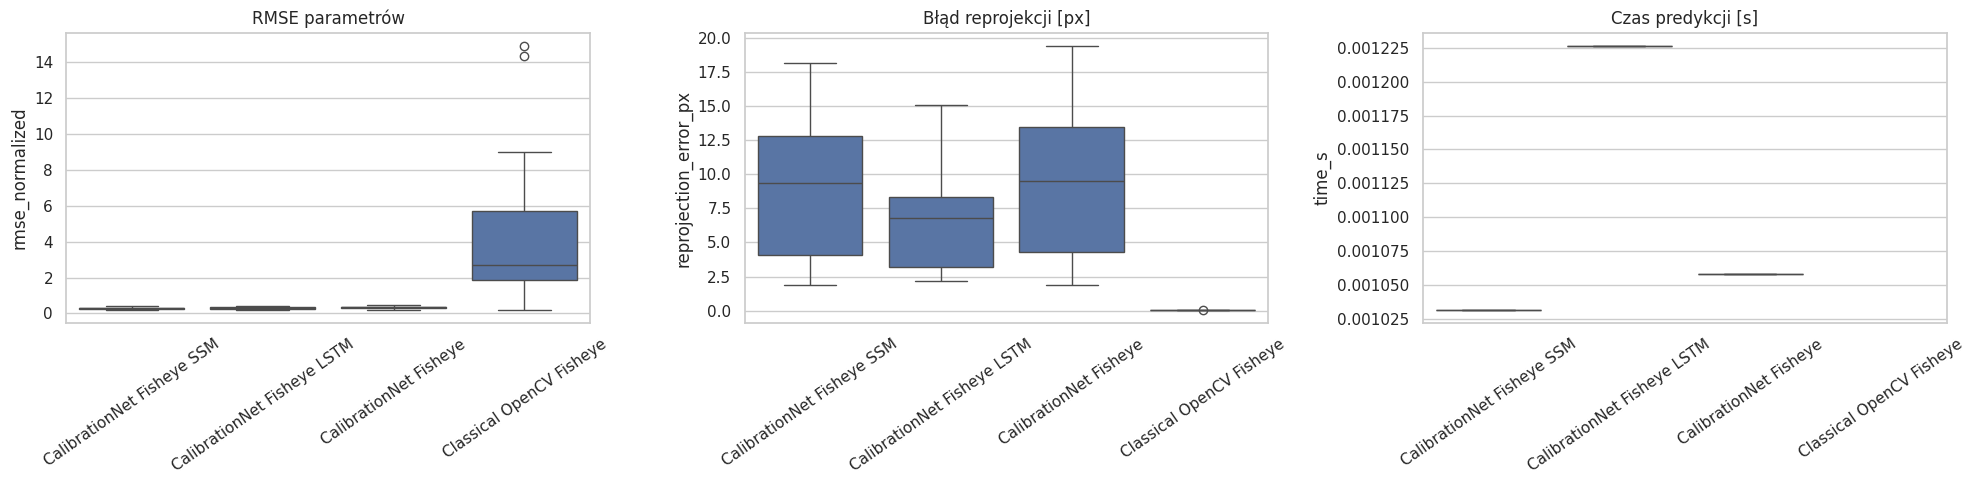

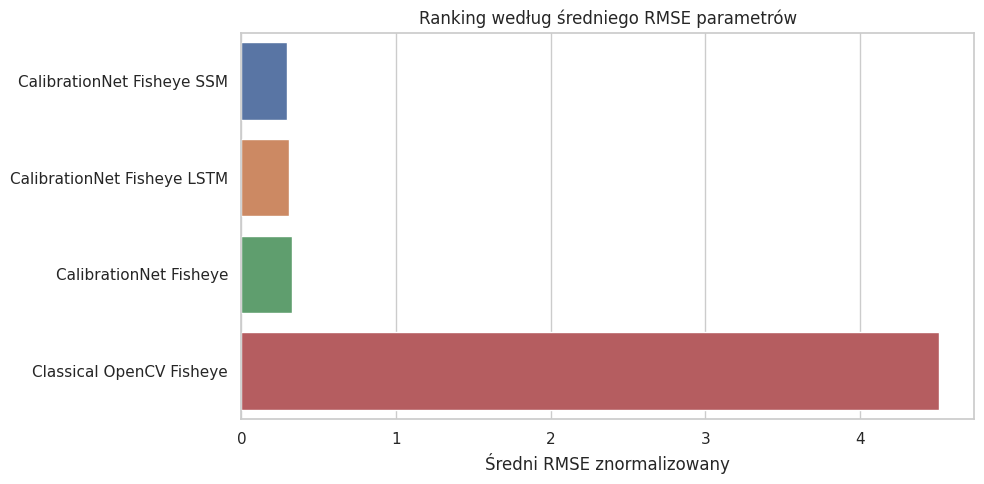

Najlepsza sieć: CalibrationNet Fisheye SSM — RMSE=0.292692, reprojekcja=8.851 px.
Najsłabsza sieć: CalibrationNet Fisheye — RMSE=0.329150, reprojekcja=9.360 px.
Klasyczny OpenCV fisheye — RMSE parametrów=4.512648, reprojekcja=0.050 px, poprawne kalibracje=100.0%.


In [14]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_order = summary_df['method'].tolist()
for ax, column, title in zip(
    axes,
    ['rmse_normalized', 'reprojection_error_px', 'time_s'],
    ['RMSE parametrów', 'Błąd reprojekcji [px]', 'Czas predykcji [s]'],
):
    sns.boxplot(data=per_sample_df, x='method', y=column, order=plot_order, ax=ax)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=35)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=summary_df, x='rmse_normalized_mean', y='method', hue='method', legend=False, ax=ax)
ax.set_title('Ranking według średniego RMSE parametrów')
ax.set_xlabel('Średni RMSE znormalizowany')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Ranking sieci jest liczony osobno od klasycznej metody referencyjnej.
neural_summary = summary_df[~summary_df['method'].str.startswith('Classical')].copy()
best_network = neural_summary.sort_values(
    ['rmse_normalized_mean', 'reprojection_error_px_mean']
).iloc[0]
worst_network = neural_summary.sort_values(
    ['rmse_normalized_mean', 'reprojection_error_px_mean'], ascending=False
).iloc[0]
classical_summary = summary_df[summary_df['method'].str.startswith('Classical')]
print(
    f"Najlepsza sieć: {best_network['method']} — "
    f"RMSE={best_network['rmse_normalized_mean']:.6f}, "
    f"reprojekcja={best_network['reprojection_error_px_mean']:.3f} px."
)
print(
    f"Najsłabsza sieć: {worst_network['method']} — "
    f"RMSE={worst_network['rmse_normalized_mean']:.6f}, "
    f"reprojekcja={worst_network['reprojection_error_px_mean']:.3f} px."
)
if not classical_summary.empty:
    classical = classical_summary.iloc[0]
    print(
        f"Klasyczny OpenCV fisheye — RMSE parametrów={classical['rmse_normalized_mean']:.6f}, "
        f"reprojekcja={classical['reprojection_error_px_mean']:.3f} px, "
        f"poprawne kalibracje={classical['valid_calibration_pct']:.1f}%."
    )

In [24]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
per_sample_export = per_sample_df.drop(columns=['prediction', 'ground_truth'], errors='ignore')
per_sample_export.to_csv(RESULTS_DIR / 'results_per_sample.csv', index=False)
summary_df.to_csv(RESULTS_DIR / 'results_summary.csv', index=False)

ranking = summary_df[['method', 'rmse_normalized_mean', 'reprojection_error_px_mean', 'valid_calibration_pct']].to_dict(orient='records')
experiment_config = {
    'data_dir': str(DATA_DIR), 'results_dir': str(RESULTS_DIR),
    'sequence_length': SEQUENCE_LENGTH, 'board_squares': [BOARD_SQUARES_X, BOARD_SQUARES_Y],
    'pattern_inner_corners': list(PATTERN_SIZE), 'image_size': [IMAGE_WIDTH, IMAGE_HEIGHT],
    'parameters': PARAMETERS, 'device': str(DEVICE), 'tolerance': TOLERANCE,
    'reprojection_success_threshold_px': 1.0,
    'checkpoints': {name: str(path) for name, path in CHECKPOINTS.items()},
    'rejected_sequences': rejected, 'ranking': ranking,
    'best_network': str(best_network['method']), 'worst_network': str(worst_network['method']),
    'classical_baseline': 'Classical OpenCV Fisheye',
}
with open(RESULTS_DIR / 'results_summary.json', 'w', encoding='utf-8') as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False, default=str)

assert pd.read_csv(RESULTS_DIR / 'results_per_sample.csv').shape == per_sample_export.shape
assert pd.read_csv(RESULTS_DIR / 'results_summary.csv').shape == summary_df.shape
with open(RESULTS_DIR / 'results_summary.json', encoding='utf-8') as f:
    json.load(f)
print(f'Zapisano wyniki w: {RESULTS_DIR}')
for path in sorted(RESULTS_DIR.glob('results_*')):
    print(path.name, path.stat().st_size, 'bytes')

Zapisano wyniki w: /home/dbabiarczyk/studia/semestr10/camera_calibration/outputs/fisheye_evaluation
results_per_sample.csv 79013 bytes
results_summary.csv 2978 bytes
results_summary.json 2109 bytes


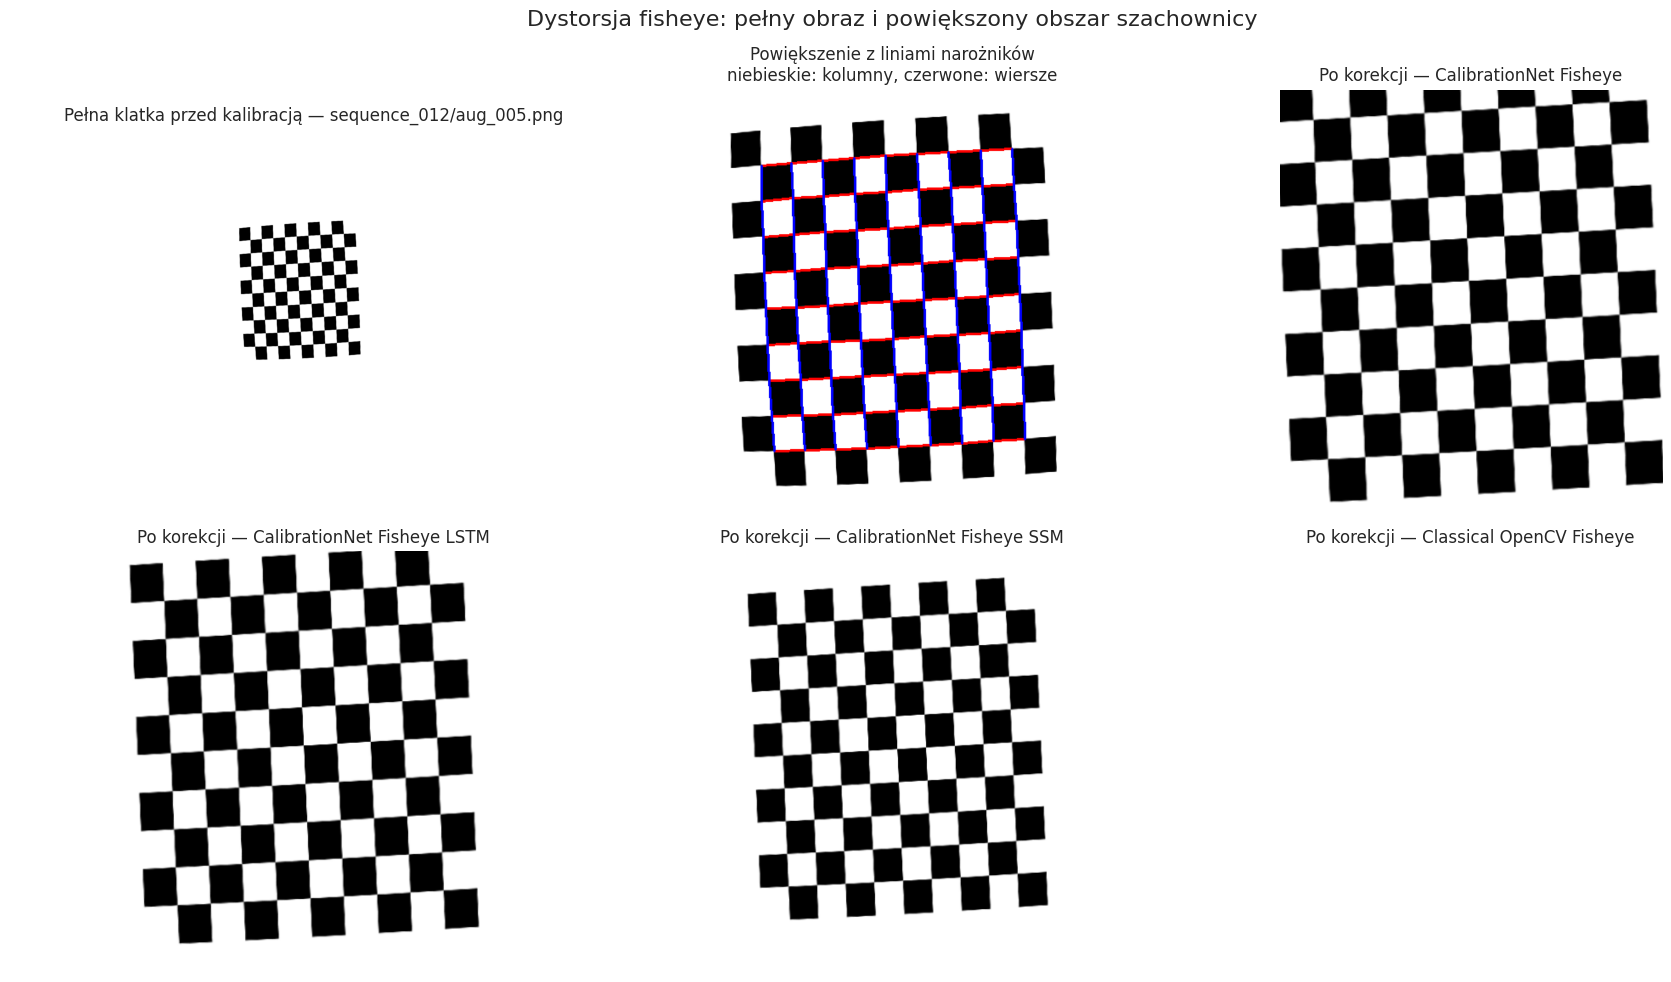

Zapisano wizualizację: /home/dbabiarczyk/studia/semestr10/camera_calibration/outputs/fisheye_evaluation/calibration_visualization_sequence_012_aug_005_zoom.png


In [46]:
# Wizualizacja dystorsji na powiększonym wycinku planszy.
# Pełna klatka sprawia, że niewielka krzywizna jest praktycznie niewidoczna.
visual_sample = next(sample for sample in samples if sample['sequence'] == 'sequence_012')
visual_frame = visual_sample['frames'][5]
original_bgr = cv2.imread(str(visual_frame), cv2.IMREAD_COLOR)
if original_bgr is None:
    raise FileNotFoundError(visual_frame)


def undistort_with_fisheye_parameters(image: np.ndarray, prediction: np.ndarray) -> np.ndarray:
    prediction = np.asarray(prediction, dtype=np.float64).reshape(8)
    K = np.array([[prediction[0], 0.0, prediction[2]],
                  [0.0, prediction[1], prediction[3]],
                  [0.0, 0.0, 1.0]], dtype=np.float64)
    D = prediction[4:8].reshape(4, 1)
    h, w = image.shape[:2]
    new_K = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
        K, D, (w, h), np.eye(3), balance=0.0
    )
    map_x, map_y = cv2.fisheye.initUndistortRectifyMap(
        K, D, np.eye(3), new_K, (w, h), cv2.CV_32FC1
    )
    return cv2.remap(image, map_x, map_y, cv2.INTER_LINEAR,
                     borderMode=cv2.BORDER_CONSTANT, borderValue=(255, 255, 255))


# Zaznaczenie wykrytych narożników i połączenie ich liniami pozwala ocenić krzywiznę.
observed = visual_sample['corners'][5].reshape(9, 9, 2)
overlay = original_bgr.copy()
for row in observed:
    cv2.polylines(overlay, [np.round(row).astype(np.int32)], False, (0, 0, 255), 2)
for column in observed.transpose(1, 0, 2):
    cv2.polylines(overlay, [np.round(column).astype(np.int32)], False, (255, 0, 0), 2)

x_min, y_min = np.floor(observed.min(axis=(0, 1)) - 70).astype(int)
x_max, y_max = np.ceil(observed.max(axis=(0, 1)) + 70).astype(int)
x_min, y_min = max(0, x_min), max(0, y_min)
x_max, y_max = min(original_bgr.shape[1], x_max), min(original_bgr.shape[0], y_max)
raw_crop = cv2.resize(original_bgr[y_min:y_max, x_min:x_max], None, fx=2.0, fy=2.0, interpolation=cv2.INTER_NEAREST)
overlay_crop = cv2.resize(overlay[y_min:y_max, x_min:x_max], None, fx=2.0, fy=2.0, interpolation=cv2.INTER_NEAREST)

visual_records = [record for record in records if record['sequence'] == 'sequence_012']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
axes[0].imshow(cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('Pełna klatka przed kalibracją — sequence_012/aug_005.png')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(overlay_crop, cv2.COLOR_BGR2RGB))
axes[1].set_title('Powiększenie z liniami narożników\nniebieskie: kolumny, czerwone: wiersze')
axes[1].axis('off')

for axis, record in zip(axes[2:], visual_records[:4]):
    corrected = undistort_with_fisheye_parameters(original_bgr, record['prediction'])
    corrected_crop = cv2.resize(corrected[y_min:y_max, x_min:x_max], None, fx=2.0, fy=2.0, interpolation=cv2.INTER_NEAREST)
    axis.imshow(cv2.cvtColor(corrected_crop, cv2.COLOR_BGR2RGB))
    axis.set_title(f"Po korekcji — {record['method']}")
    axis.axis('off')

for axis in axes[len(visual_records[:4]) + 2:]:
    axis.axis('off')
fig.suptitle('Dystorsja fisheye: pełny obraz i powiększony obszar szachownicy', fontsize=16)
plt.tight_layout()
visualization_path = RESULTS_DIR / 'calibration_visualization_sequence_012_aug_005_zoom.png'
fig.savefig(visualization_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Zapisano wizualizację: {visualization_path}')